# Household Energy Consumption Analysis

## 1. Installing Required Libraries

In [1]:
!pip install pandas
!pip install pandas matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Converting the Dataset from TXT to CSV

In [2]:
import pandas as pd

df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values="?",
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 3. Importing Libraries and Loading the CSV File

In [3]:
df.to_csv("household_power_consumption.csv", index=False)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("household_power_consumption.csv")

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 4. Initial Data Exploration

In [5]:
print("Shape:", df.shape)

print("\nData Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (2075259, 9)

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB

Missing Values:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


## 5. Understanding Columns and Data Types

In [6]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
df.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='str')

In [8]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


## 6. Combining Date and Time Columns

In [9]:
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True,
    errors="coerce"
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [10]:
df["DateTime"].isnull().sum()

np.int64(0)

## 7. Creating Time-Based Features

In [11]:
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["Weekday"] = df["DateTime"].dt.day_name()

df[["DateTime", "Year", "Month", "Day", "Hour", "Weekday"]].head()

,DateTime,Year,Month,Day,Hour,Weekday
0,2006-12-16 17:24:00,2006,12,16,17,Saturday
1,2006-12-16 17:25:00,2006,12,16,17,Saturday
2,2006-12-16 17:26:00,2006,12,16,17,Saturday
3,2006-12-16 17:27:00,2006,12,16,17,Saturday
4,2006-12-16 17:28:00,2006,12,16,17,Saturday


## 8. Checking Missing Values After Transformation

In [12]:
df.isnull().sum()

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
DateTime                     0
Year                         0
Month                        0
Day                          0
Hour                         0
Weekday                      0
dtype: int64

In [13]:
df.shape

(2075259, 15)

## 9. Handling Missing Values

In [14]:
df = df.dropna()

df.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
DateTime                 0
Year                     0
Month                    0
Day                      0
Hour                     0
Weekday                  0
dtype: int64

In [15]:
df.shape

(2049280, 15)

## 10. Creating Total Sub-Metering Consumption Column

In [16]:
df["Sub_metering_total"] = (
    df["Sub_metering_1"] +
    df["Sub_metering_2"] +
    df["Sub_metering_3"]
)

df[["Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "Sub_metering_total"]].head()

,Sub_metering_1,Sub_metering_2,Sub_metering_3,Sub_metering_total
0,0.0,1.0,17.0,18.0
1,0.0,1.0,16.0,17.0
2,0.0,2.0,17.0,19.0
3,0.0,1.0,17.0,18.0
4,0.0,1.0,17.0,18.0


## 11. Creating Key Performance Indicators KPIs

In [17]:
avg_power = df["Global_active_power"].mean()
max_power = df["Global_active_power"].max()
min_power = df["Global_active_power"].min()
avg_voltage = df["Voltage"].mean()
avg_intensity = df["Global_intensity"].mean()

print("Average Global Active Power:", round(avg_power, 2), "kilowatts")
print("Maximum Global Active Power:", round(max_power, 2), "kilowatts")
print("Minimum Global Active Power:", round(min_power, 2), "kilowatts")
print("Average Voltage:", round(avg_voltage, 2), "volts")
print("Average Global Intensity:", round(avg_intensity, 2), "amps")

Average Global Active Power: 1.09 kilowatts
Maximum Global Active Power: 11.12 kilowatts
Minimum Global Active Power: 0.08 kilowatts
Average Voltage: 240.84 volts
Average Global Intensity: 4.63 amps


## 12. Hourly Energy Consumption Analysis

In [18]:
hourly_consumption = df.groupby("Hour")["Global_active_power"].mean()

hourly_consumption

Hour
0     0.659434
1     0.539325
2     0.480621
3     0.444866
4     0.443847
5     0.453674
6     0.791600
7     1.502246
8     1.461016
9     1.331645
10    1.260627
11    1.245822
12    1.207075
13    1.144532
14    1.082839
15    0.990760
16    0.948905
17    1.055109
18    1.326451
19    1.733335
20    1.899064
21    1.877697
22    1.412615
23    0.902142
Name: Global_active_power, dtype: float64

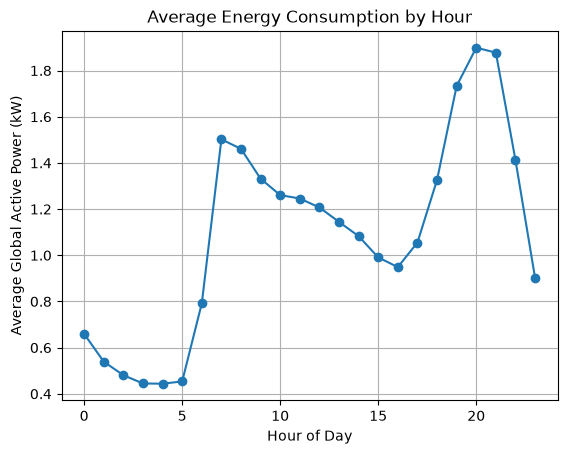

In [19]:
hourly_consumption.plot(kind="line", marker="o")

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power (kW)")
plt.grid(True)
plt.show()

## 13. Energy Consumption by Weekday

In [20]:
weekday_consumption = df.groupby("Weekday")["Global_active_power"].mean()

weekday_consumption

Weekday
Friday       1.043394
Monday       0.999546
Saturday     1.248335
Sunday       1.220188
Thursday     0.981809
Tuesday      1.069796
Wednesday    1.082588
Name: Global_active_power, dtype: float64

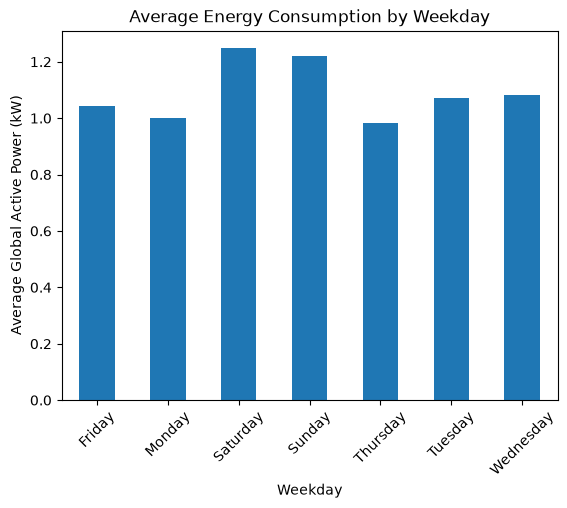

In [21]:
weekday_consumption.plot(kind="bar")

plt.title("Average Energy Consumption by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Global Active Power (kW)")
plt.xticks(rotation=45)
plt.show()

## 14. Monthly Energy Consumption Analysis

In [22]:
monthly_consumption = df.groupby("Month")["Global_active_power"].mean()

monthly_consumption

Month
1     1.462226
2     1.300431
3     1.231343
4     1.047146
5     1.029571
6     0.909148
7     0.700359
8     0.572812
9     0.975653
10    1.137141
11    1.291532
12    1.489729
Name: Global_active_power, dtype: float64

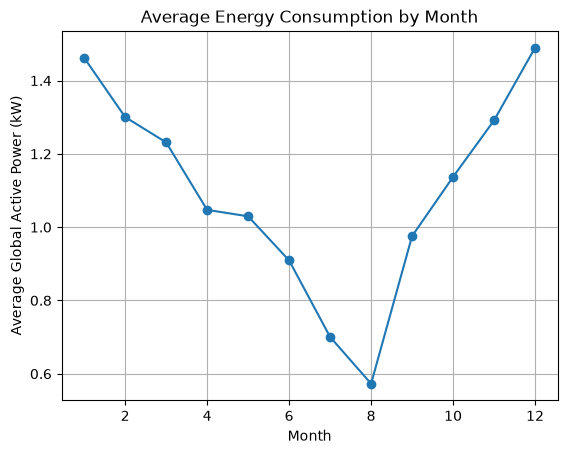

In [23]:
monthly_consumption.plot(kind="line", marker="o")

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Global Active Power (kW)")
plt.grid(True)
plt.show()

## 15. Weekday vs Weekend Energy Consumption

In [24]:
df["Day_Type"] = df["Weekday"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

df[["Weekday", "Day_Type"]].head()

,Weekday,Day_Type
0,Saturday,Weekend
1,Saturday,Weekend
2,Saturday,Weekend
3,Saturday,Weekend
4,Saturday,Weekend


In [25]:
day_type_consumption = df.groupby("Day_Type")["Global_active_power"].mean()

day_type_consumption

Day_Type
Weekday    1.035472
Weekend    1.234232
Name: Global_active_power, dtype: float64

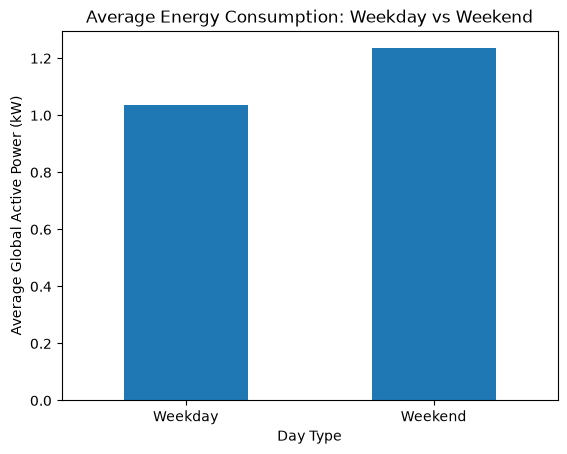

In [26]:
day_type_consumption.plot(kind="bar")

plt.title("Average Energy Consumption: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Global Active Power (kW)")
plt.xticks(rotation=0)
plt.show()

## 16. Daily Energy Consumption Trend

In [27]:
daily_consumption = df.groupby(df["DateTime"].dt.date)["Global_active_power"].mean()

daily_consumption.head()

DateTime
2006-12-16    3.053475
2006-12-17    2.354486
2006-12-18    1.530435
2006-12-19    1.157079
2006-12-20    1.545658
Name: Global_active_power, dtype: float64

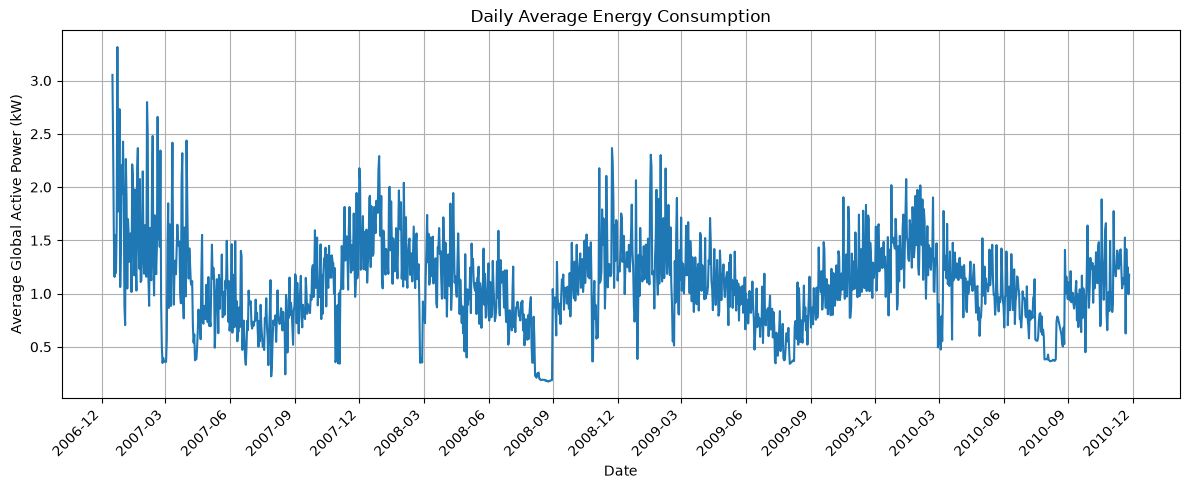

In [29]:
import matplotlib.dates as mdates

daily_consumption = df.groupby(df["DateTime"].dt.date)["Global_active_power"].mean()
daily_consumption.index = pd.to_datetime(daily_consumption.index)

daily_consumption.plot(kind="line", figsize=(12, 5))

plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Global Active Power (kW)")
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17. Top 10 Days by Energy Consumption

In [30]:
top_10_days = daily_consumption.sort_values(ascending=False).head(10)

top_10_days

DateTime
2006-12-23    3.314851
2006-12-16    3.053475
2007-02-03    2.798418
2006-12-26    2.732021
2007-02-18    2.659557
2007-02-04    2.497181
2007-02-11    2.480019
2007-03-31    2.437160
2006-12-31    2.426525
2007-03-11    2.417108
Name: Global_active_power, dtype: float64

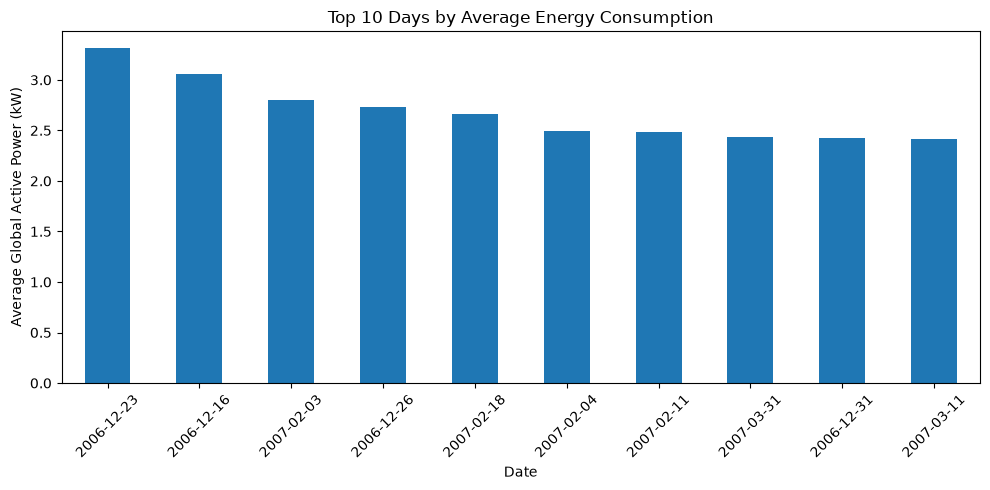

In [32]:
top_10_days = daily_consumption.sort_values(ascending=False).head(10)

top_10_days.index = top_10_days.index.strftime("%Y-%m-%d")

top_10_days.plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Days by Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Global Active Power (kW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Peak Consumption Hours Analysis

In [33]:
peak_hours = hourly_consumption.sort_values(ascending=False).head(5)

peak_hours

Hour
20    1.899064
21    1.877697
19    1.733335
7     1.502246
8     1.461016
Name: Global_active_power, dtype: float64

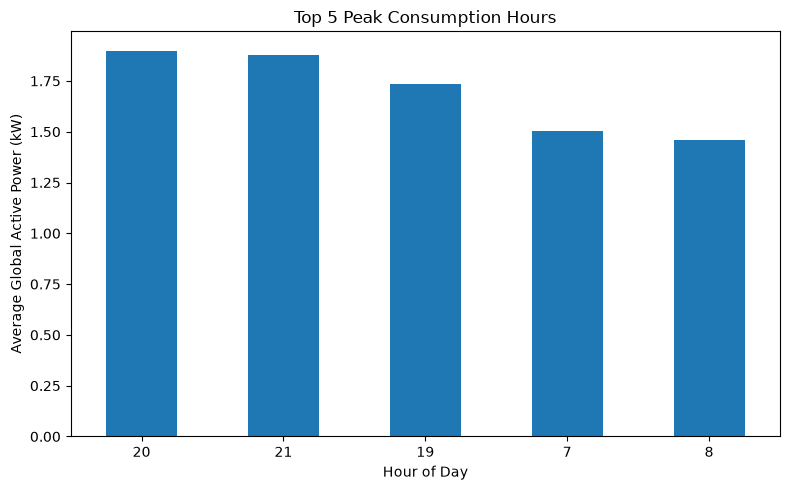

In [34]:
peak_hours.plot(kind="bar", figsize=(8, 5))

plt.title("Top 5 Peak Consumption Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power (kW)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 19. Creating Season Column

In [35]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df[["Month", "Season"]].head()

,Month,Season
0,12,Winter
1,12,Winter
2,12,Winter
3,12,Winter
4,12,Winter


## 20. Seasonal Energy Consumption Analysis

In [36]:
season_consumption = df.groupby("Season")["Global_active_power"].mean()

season_consumption

Season
Autumn    1.134610
Spring    1.103194
Summer    0.726682
Winter    1.417623
Name: Global_active_power, dtype: float64

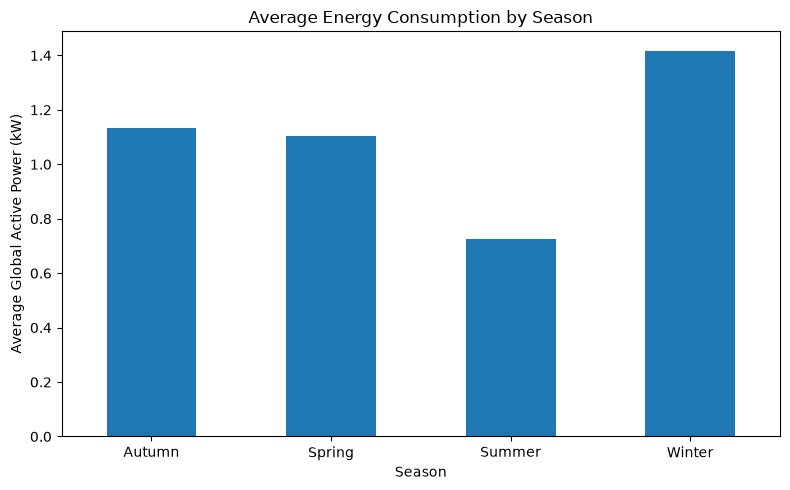

In [37]:
season_consumption.plot(kind="bar", figsize=(8, 5))

plt.title("Average Energy Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Average Global Active Power (kW)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 21. Saving the Cleaned Dataset

In [38]:
df.to_csv("clean_energy_consumption_data.csv", index=False)

## Key Insights

- The dataset contains more than 2 million household electricity consumption records.
- The average global active power is approximately 1.09 kW.
- The maximum global active power is 11.12 kW.
- The average voltage is approximately 240.84 volts.
- Energy consumption is higher during evening hours, especially around 20:00 and 21:00.
- Winter has the highest average energy consumption.
- Summer has the lowest average energy consumption.
- Daily electricity consumption shows noticeable fluctuations over time.

## Conclusion

This project analyzed household electricity consumption data to understand energy usage patterns over time. The analysis showed that energy consumption varies by hour, day, month, and season. The highest consumption occurs during evening peak hours and during winter months, while summer shows the lowest average consumption. The cleaned dataset can be used to build an interactive Power BI dashboard for further exploration.